### **Text Classification using RNN**
- Prepared By: **Aayush Khatiwada**  
- L6CG13 | Student ID: 2407726

In this notebook, I have designed a RNN model that classifies the News Cagetory based on the News Headline

#**Load libraries and dataset**

##**Install and Load libraries**


In [6]:
!pip install contractions
!pip install gensim
!pip install gradio

In [85]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

import nltk
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tensorflow.keras.preprocessing.text import Tokenizer
from keras.models import Sequential
from keras.layers import Input, Embedding, SimpleRNN, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.utils import pad_sequences

import pickle
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import gensim.downloader as api

import gradio as gr

##**Download NLTK resources**

In [8]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

##**Load Dataset**

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
df = pd.read_csv("/content/drive/MyDrive/AI and ML/Coursework/Task III/news_category.csv")

#**Explore Dataset**

##**Basic info**

In [11]:
df.head()

,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11025 entries, 0 to 11024
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   headline  11025 non-null  object
 1   category  11025 non-null  object
dtypes: object(2)
memory usage: 172.4+ KB


##**Class Distribution**

In [13]:
df['category'].value_counts()

,count
category,
SPORTS,5077
TECH,2104
MONEY,1756
CULTURE & ARTS,1074
EDUCATION,1014


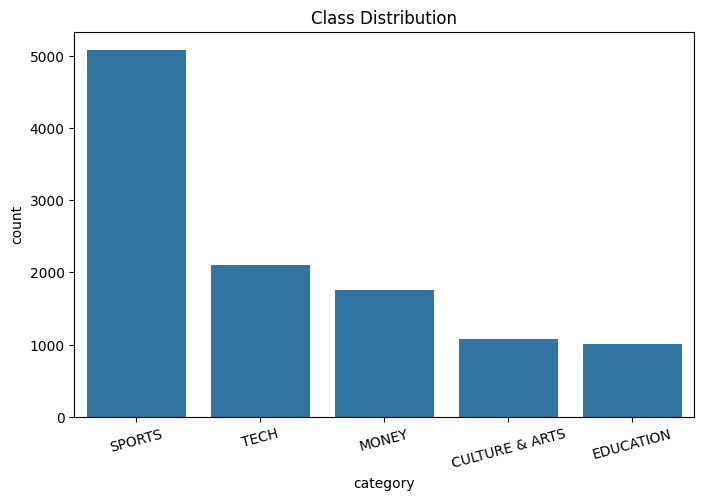

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='category',
    order=df['category'].value_counts().index
)

plt.title("Class Distribution")
plt.xticks(rotation=15)
plt.show()

#**Data Preprocessing**

##**Cleaning pipeline**

In [15]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenize
    words = text.split()

    # light stopword removal + lemmatization
    cleaned_words = []

    for word in words:
        if word not in stop_words:
            lemma = lemmatizer.lemmatize(word)
            cleaned_words.append(lemma)

    cleaned_text = " ".join(cleaned_words)

    # expand contractions
    fixed_text = contractions.fix(cleaned_text)

    return fixed_text

In [16]:
df['cleaned_headline'] = df['headline'].apply(clean_text)

In [17]:
for i in range(13):

    print("RAW:")
    print(df.iloc[i]['headline'])

    print("\nCLEANED:")
    print(df.iloc[i]['cleaned_headline'])

    print("-" * 60)

RAW:
How A New Documentary Captures The Complexity Of Being A Child Of Immigrants

CLEANED:
new documentary capture complexity child immigrant
------------------------------------------------------------
RAW:
Twitch Bans Gambling Sites After Streamer Scams Folks Out Of $200,000

CLEANED:
twitch ban gambling site streamer scam folk
------------------------------------------------------------
RAW:
'Reboot' Is A Clever And Not Too Navel-Gazey Look Inside TV Reboots

CLEANED:
reboot clever navelgazey look inside tv reboots
------------------------------------------------------------
RAW:
Maury Wills, Base-Stealing Shortstop For Dodgers, Dies At 89

CLEANED:
maury will basestealing shortstop dodger dy
------------------------------------------------------------
RAW:
Las Vegas Aces Win First WNBA Title, Chelsea Gray Named MVP

CLEANED:
la vega ace win first wnba title chelsea gray named mvp
------------------------------------------------------------
RAW:
Meet Alex Aster, The TikToker Changi

Limitations of Lemmatization:
- named entities may be altered
- contextual meaning may slightly shift

Example: flowers(surname) → flower

##**Label Encoding**

In [18]:
# Encode labels
label_encoder = LabelEncoder()

df['label'] = label_encoder.fit_transform(df['category'])

In [19]:
# Save label mapping for use in inference
label_mapping = dict(
    zip(label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_))
)

print(label_mapping)

{'CULTURE & ARTS': np.int64(0), 'EDUCATION': np.int64(1), 'MONEY': np.int64(2), 'SPORTS': np.int64(3), 'TECH': np.int64(4)}


In [20]:
label_mapping_serializable = {k: int(v) for k, v in label_mapping.items()}
with open("label_mapping.json", "w") as f:
    json.dump(label_mapping_serializable, f)

##**Split Dataset**

In [21]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

In [22]:
print(train_df.shape)
print(test_df.shape)

(8820, 4)
(2205, 4)


##**Tokenization**

In [23]:
# Configure tokenizer
vocab_size = 10000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

In [24]:
tokenizer.fit_on_texts(df['cleaned_headline'])

In [25]:
# Inspect vocabulary size
word_index = tokenizer.word_index

print("Vocabulary Size:", len(word_index))

Vocabulary Size: 13485


In [26]:
X_train_seq = tokenizer.texts_to_sequences(
    train_df['cleaned_headline']
)

X_test_seq = tokenizer.texts_to_sequences(
    test_df['cleaned_headline']
)

In [27]:
print(train_df['cleaned_headline'].iloc[0])

print(X_train_seq[0])

here need know apple fbi showdown dc
[80, 65, 68, 13, 366, 2624, 681]


In [28]:
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

##**Padding**

In [29]:
max_len = 12

X_train = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

In [30]:
y_train = train_df['label']
y_test = test_df['label']

In [31]:
print(X_train.shape)

(8820, 12)


##**Calculate class weights**

In [32]:
y_train = np.array(y_train)
y_test = np.array(y_test)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(2.053550640279395), 1: np.float64(2.1750924784217016), 2: np.float64(1.2555160142348754), 3: np.float64(0.4342688330871492), 4: np.float64(1.0481283422459893)}


#**Frequency and length analysis**

##**Word Frequency Analysis**

In [33]:
all_words = " ".join(df['cleaned_headline'])

word_counts = Counter(all_words.split())

common_words = word_counts.most_common(20)

common_df = pd.DataFrame(common_words, columns=['Word', 'Count'])

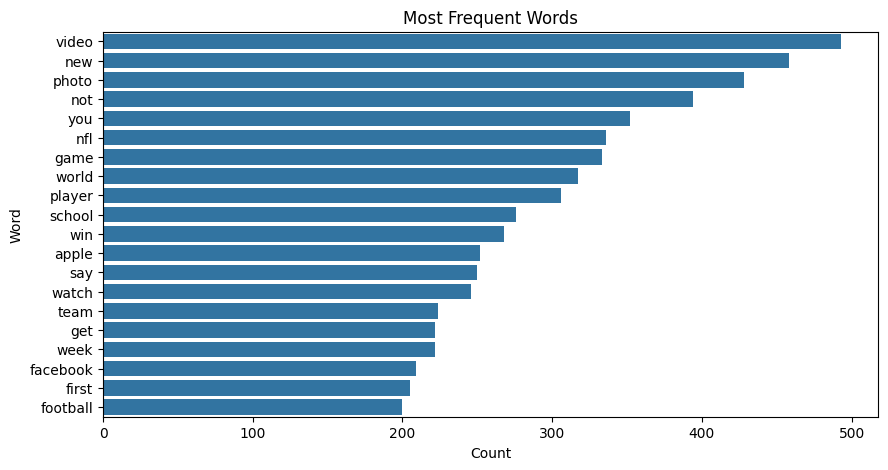

In [34]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=common_df,
    x='Count',
    y='Word'
)

plt.title("Most Frequent Words")
plt.show()

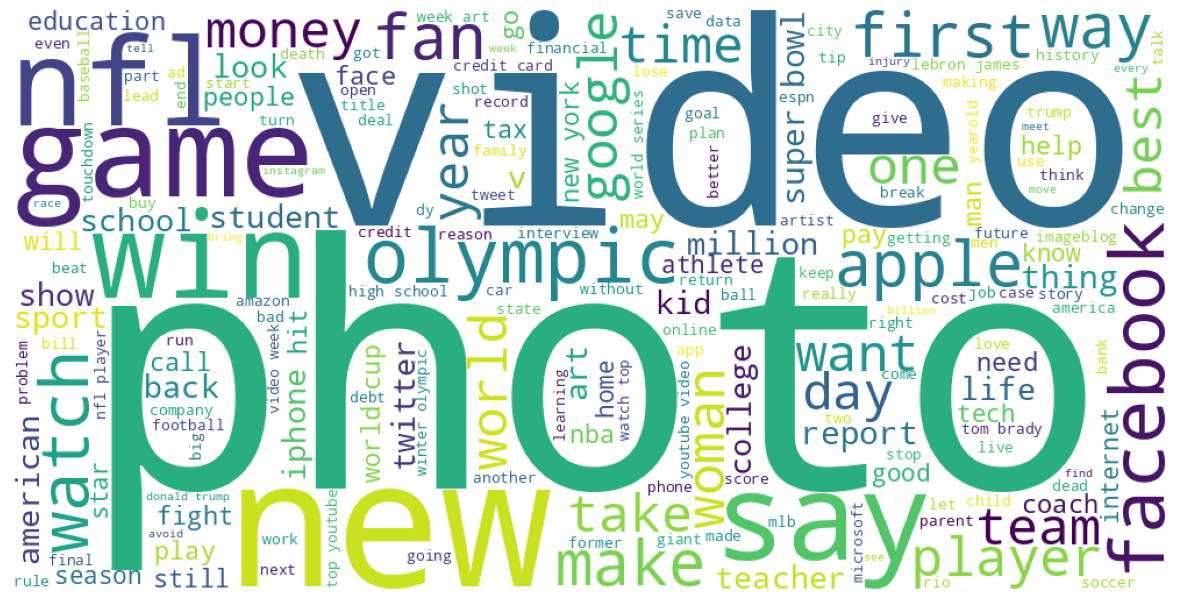

In [35]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [36]:
df.to_csv("cleaned_news_dataset.csv", index=False)

##**Sequence length analysis**

In [37]:
sequence_lengths = df['cleaned_headline'].apply(
    lambda x: len(x.split())
)

In [38]:
print(sequence_lengths.describe())

count    11025.000000
mean         6.976145
std          2.430469
min          1.000000
25%          5.000000
50%          7.000000
75%          9.000000
max         19.000000
Name: cleaned_headline, dtype: float64


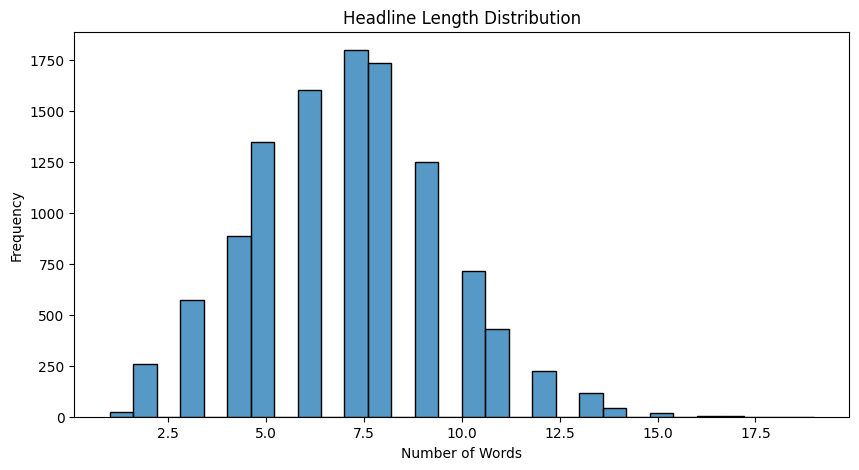

In [39]:
plt.figure(figsize=(10,5))

sns.histplot(sequence_lengths, bins=30)

plt.title("Headline Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

Choosing 12 as the maximum lenth of the input sequence for padding and truncation

In [40]:
max_len = 12

#**RNN Model**

##**Model Definition**

In [41]:
# Define hyperparameters to be used
embedding_dim = 128
rnn_units = 64

In [42]:
# Define the model architecture
model_rnn = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
    ),

    SimpleRNN(rnn_units),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(len(label_mapping), activation='softmax')
])

##**Model Summary**

In [43]:
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 12, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,296,837 (4.95 MB)

 Trainable params: 1,296,837 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

##**Callbacks**

In [44]:
callbacks = [
    EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
),

ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    verbose=1,
    patience=2
)
]

##**Compile Model**

In [45]:
model_rnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##**Train Model**

In [46]:
history_rnn = model_rnn.fit(
    X_train,
    y_train,

    validation_split=0.2,

    epochs=15,

    batch_size=32,

    callbacks=callbacks,

    class_weight=class_weights
)

Epoch 1/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5577 - loss: 1.1575 - val_accuracy: 0.7653 - val_loss: 0.6666 - learning_rate: 0.0010
Epoch 2/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8849 - loss: 0.4025 - val_accuracy: 0.8090 - val_loss: 0.5801 - learning_rate: 0.0010
Epoch 3/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9623 - loss: 0.1438 - val_accuracy: 0.7778 - val_loss: 0.7712 - learning_rate: 0.0010
Epoch 4/15
213/221 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9806 - loss: 0.0655
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9793 - loss: 0.0702 - val_accuracy: 0.8005 - val_loss: 0.7499 - learning_rate: 0.0010
Epoch 5/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9940 - loss: 0.0249 - val_accuracy: 0.8203 - val_loss: 0.8002 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [47]:
# Save model
model_rnn.save("/content/model_rnn.keras")

##**Accuracy and loss curves**

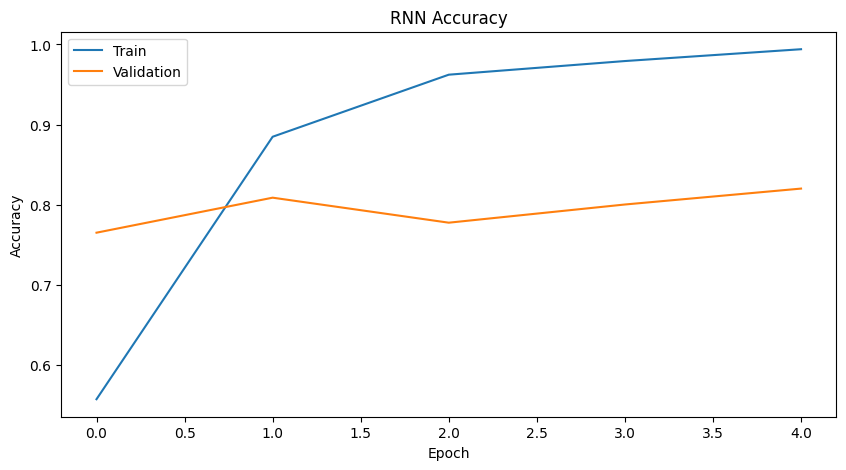

In [48]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['accuracy'])
plt.plot(history_rnn.history['val_accuracy'])

plt.title("RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

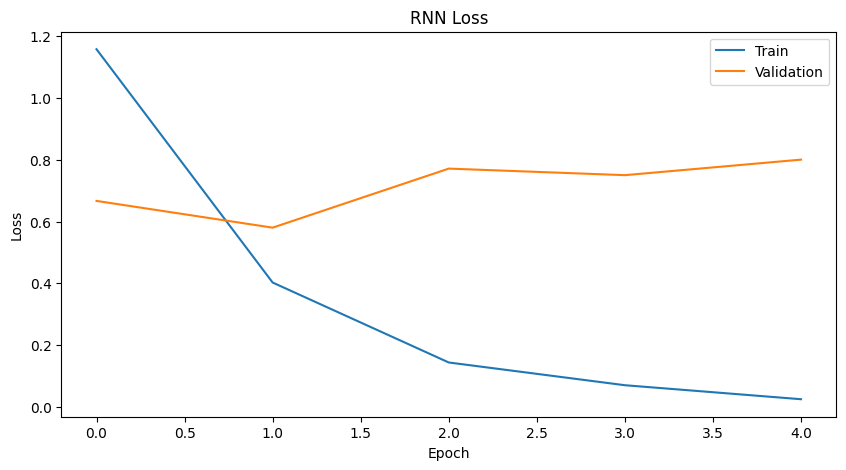

In [49]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['loss'])
plt.plot(history_rnn.history['val_loss'])

plt.title("RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

##**Model Evaluation**

In [50]:
test_loss, test_acc = model_rnn.evaluate(
    X_test,
    y_test
)

print(test_acc)

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7941 - loss: 0.6161
0.7941043376922607


In [51]:
y_pred_probs = model_rnn.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [52]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_mapping.keys()
    )
)

                precision    recall  f1-score   support

CULTURE & ARTS       0.70      0.74      0.72       215
     EDUCATION       0.56      0.82      0.67       203
         MONEY       0.69      0.72      0.71       351
        SPORTS       0.95      0.86      0.90      1015
          TECH       0.75      0.71      0.73       421

      accuracy                           0.79      2205
     macro avg       0.73      0.77      0.75      2205
  weighted avg       0.81      0.79      0.80      2205



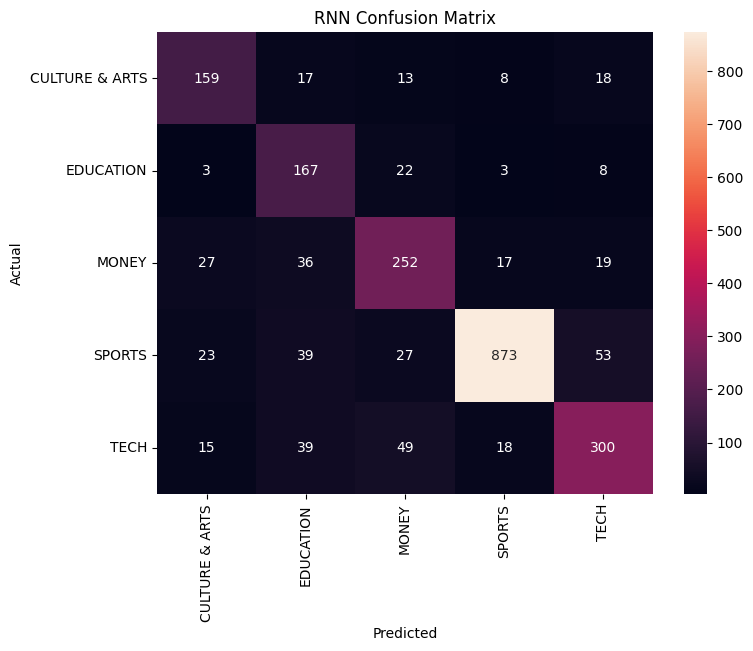

In [53]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_mapping.keys(),
    yticklabels=label_mapping.keys()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("RNN Confusion Matrix")

plt.show()

##**Misclassified Examples**

In [54]:
misclassified = np.where(y_pred != y_test)[0]

for i in misclassified[:10]:

    print("Headline :", test_df.iloc[i]['headline'])
    print("Cleaned  :", test_df.iloc[i]['cleaned_headline'])
    print("Actual   :", test_df.iloc[i]['category'])
    print("Predicted:", label_encoder.inverse_transform(
        [y_pred[i]]
    )[0])

    print("-" * 60)

Headline : The Game Boy Of Your Childhood Dreams Finally Exists
Cleaned  : game boy childhood dream finally exists
Actual   : TECH
Predicted: EDUCATION
------------------------------------------------------------
Headline : Judicial Negligence Compounds Political Negligence In South Carolina
Cleaned  : judicial negligence compound political negligence south carolina
Actual   : EDUCATION
Predicted: SPORTS
------------------------------------------------------------
Headline : Should I Go Back to Grad School?
Cleaned  : go back grad school
Actual   : MONEY
Predicted: EDUCATION
------------------------------------------------------------
Headline : Social Media Con Artists
Cleaned  : social medium con artist
Actual   : TECH
Predicted: EDUCATION
------------------------------------------------------------
Headline : Teach For America’s Houston T-shirt Sale
Cleaned  : teach america houston tshirt sale
Actual   : EDUCATION
Predicted: MONEY
----------------------------------------------------

#**LSTM Model**

##**Model Definition**

In [55]:
lstm_units = 64

In [56]:
# Define the model architecture
model_lstm = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
    ),

    LSTM(lstm_units),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(len(label_mapping), activation='softmax')
])

##**Model Summary**

In [57]:
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 12, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,333,893 (5.09 MB)

 Trainable params: 1,333,893 (5.09 MB)

 Non-trainable params: 0 (0.00 B)

##**Compile Model**

In [58]:
model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##**Train Model**

In [59]:
history_lstm = model_lstm.fit(
    X_train,
    y_train,

    validation_split=0.2,

    epochs=15,

    batch_size=32,

    callbacks=callbacks,

    class_weight=class_weights
)

Epoch 1/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5458 - loss: 1.1316 - val_accuracy: 0.7636 - val_loss: 0.6797 - learning_rate: 0.0010
Epoch 2/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8712 - loss: 0.4448 - val_accuracy: 0.8101 - val_loss: 0.5512 - learning_rate: 0.0010
Epoch 3/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9406 - loss: 0.2232 - val_accuracy: 0.8209 - val_loss: 0.5692 - learning_rate: 0.0010
Epoch 4/15
214/221 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9728 - loss: 0.1067
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9694 - loss: 0.1142 - val_accuracy: 0.8022 - val_loss: 0.7382 - learning_rate: 0.0010
Epoch 5/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9875 - loss: 0.0476 - val_accuracy: 0.8271 - val_loss: 0.7980 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [60]:
# Save model
model_lstm.save("/content/model_lstm.keras")

##**Accuracy and loss curves**

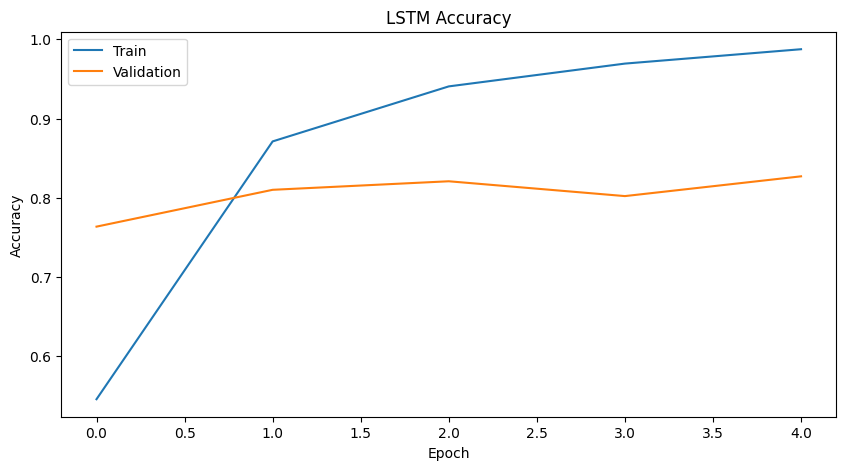

In [61]:
plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

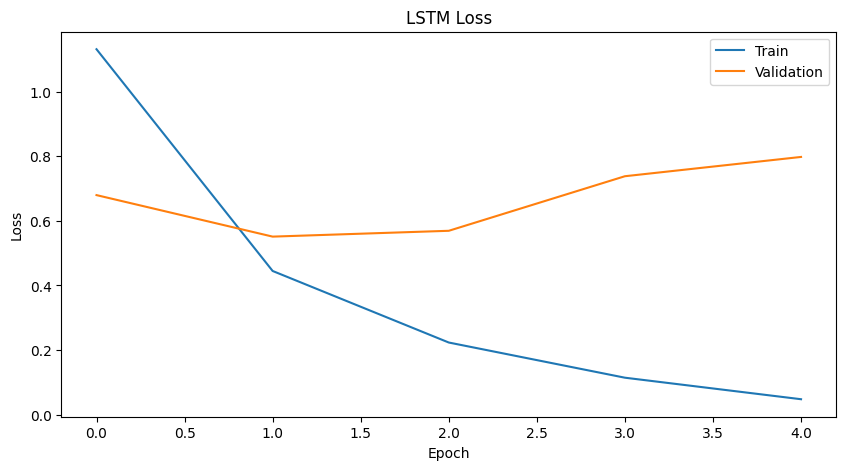

In [62]:
plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

##**Model Evaluation**

In [63]:
test_loss, test_acc = model_lstm.evaluate(
    X_test,
    y_test
)

print(test_acc)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8163 - loss: 0.5274
0.8163265585899353


In [64]:
y_pred_probs = model_lstm.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [65]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_mapping.keys()
    )
)

                precision    recall  f1-score   support

CULTURE & ARTS       0.64      0.74      0.69       215
     EDUCATION       0.74      0.67      0.71       203
         MONEY       0.72      0.81      0.76       351
        SPORTS       0.95      0.85      0.90      1015
          TECH       0.75      0.85      0.80       421

      accuracy                           0.82      2205
     macro avg       0.76      0.79      0.77      2205
  weighted avg       0.83      0.82      0.82      2205



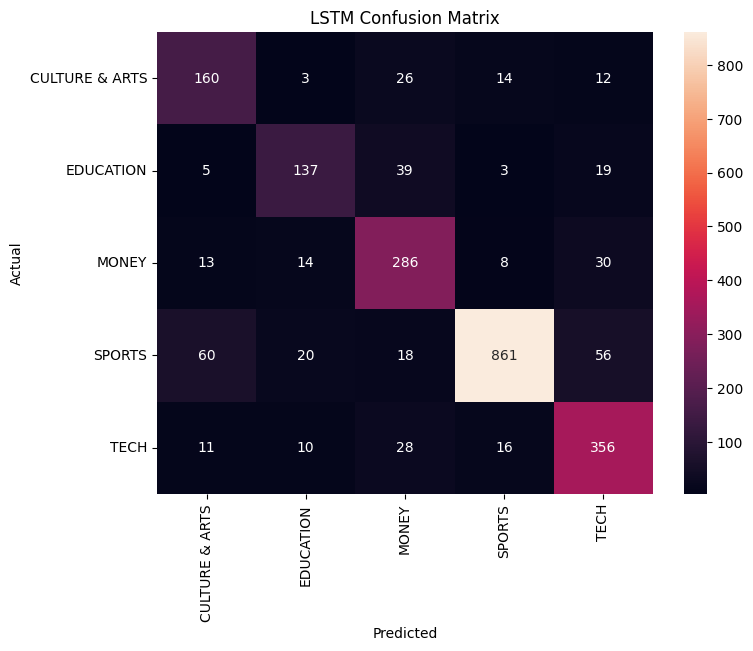

In [66]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_mapping.keys(),
    yticklabels=label_mapping.keys()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("LSTM Confusion Matrix")

plt.show()

##**Misclassified Examples**

In [67]:
misclassified = np.where(y_pred != y_test)[0]

for i in misclassified[:10]:

    print("Headline :", test_df.iloc[i]['headline'])
    print("Cleaned  :", test_df.iloc[i]['cleaned_headline'])
    print("Actual   :", test_df.iloc[i]['category'])
    print("Predicted:", label_encoder.inverse_transform(
        [y_pred[i]]
    )[0])

    print("-" * 60)

Headline : The Game Boy Of Your Childhood Dreams Finally Exists
Cleaned  : game boy childhood dream finally exists
Actual   : TECH
Predicted: EDUCATION
------------------------------------------------------------
Headline : Judicial Negligence Compounds Political Negligence In South Carolina
Cleaned  : judicial negligence compound political negligence south carolina
Actual   : EDUCATION
Predicted: CULTURE & ARTS
------------------------------------------------------------
Headline : Tales From The Autism Spectrum: My Friend AmberDawn...
Cleaned  : tale autism spectrum friend amberdawn
Actual   : CULTURE & ARTS
Predicted: TECH
------------------------------------------------------------
Headline : Should I Go Back to Grad School?
Cleaned  : go back grad school
Actual   : MONEY
Predicted: EDUCATION
------------------------------------------------------------
Headline : Social Media Con Artists
Cleaned  : social medium con artist
Actual   : TECH
Predicted: CULTURE & ARTS
-----------------

#**LSTM model with Word2Vec embeddings**

##**Embedding matrix Creation**

In [68]:
embedding_model = api.load("glove-twitter-100")

[==================================================] 100.0% 387.1/387.1MB downloaded


In [69]:
embedding_dim = 100

In [70]:
word_index = tokenizer.word_index

embedding_matrix = np.zeros(
    (vocab_size, embedding_dim)
)

In [71]:
for word, index in word_index.items():

    if index >= vocab_size:
        continue

    try:
        embedding_vector = embedding_model[word]

        embedding_matrix[index] = embedding_vector

    except KeyError:
        # word not found
        continue

##**Model definition**

In [72]:
model_glove = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),

    LSTM(lstm_units),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(len(label_mapping), activation='softmax')
])

##**Model Summary**

In [73]:
model_glove.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

##**Compile Model**

In [74]:
model_glove.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##**Train Model**

In [75]:
history_glove = model_glove.fit(
    X_train,
    y_train,

    validation_split=0.2,

    epochs=15,

    batch_size=32,

    callbacks=callbacks,

    class_weight=class_weights
)

Epoch 1/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7425 - loss: 0.8711 - val_accuracy: 0.8044 - val_loss: 0.5912 - learning_rate: 0.0010
Epoch 2/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8397 - loss: 0.5457 - val_accuracy: 0.8243 - val_loss: 0.4997 - learning_rate: 0.0010
Epoch 3/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8579 - loss: 0.4769 - val_accuracy: 0.8481 - val_loss: 0.4572 - learning_rate: 0.0010
Epoch 4/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8710 - loss: 0.4313 - val_accuracy: 0.8379 - val_loss: 0.4533 - learning_rate: 0.0010
Epoch 5/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8842 - loss: 0.3922 - val_accuracy: 0.8503 - val_loss: 0.4320 - learning_rate: 0.0010
Epoch 6/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8934 - loss: 0.3554 - val_accuracy: 0.8458 - val_loss: 0.4575 - learning_rate: 0.0010
Epoch 7/15
212/221 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9119 - loss: 0.2970
E

In [76]:
# Save model
model_glove.save("/content/model_glove.keras")

##**Accuracy and loss curves**

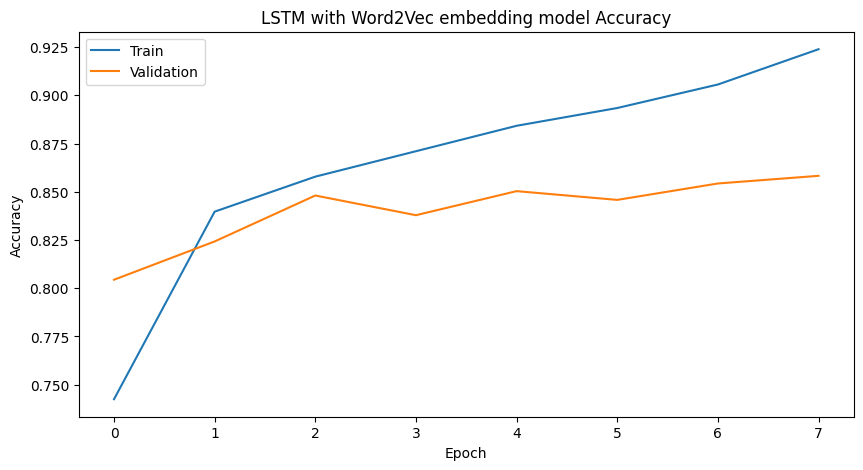

In [77]:
plt.figure(figsize=(10,5))

plt.plot(history_glove.history['accuracy'])
plt.plot(history_glove.history['val_accuracy'])

plt.title("LSTM with Word2Vec embedding model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

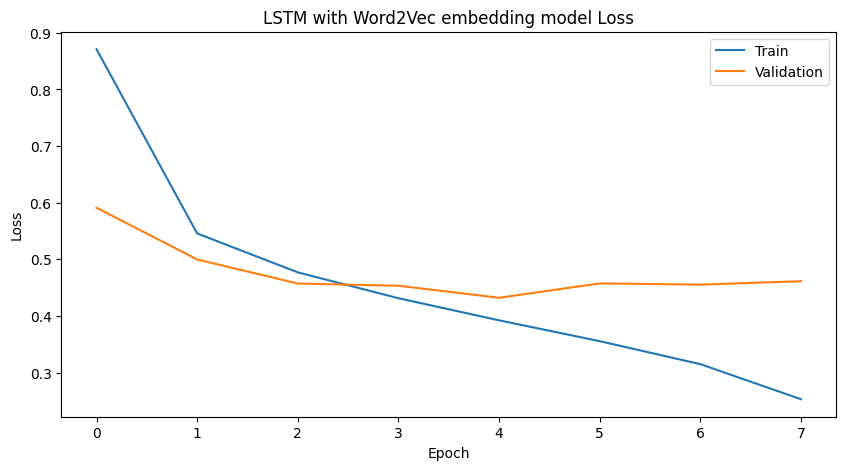

In [78]:
plt.figure(figsize=(10,5))

plt.plot(history_glove.history['loss'])
plt.plot(history_glove.history['val_loss'])

plt.title("LSTM with Word2Vec embedding model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

##**Model Evaluation**

In [79]:
test_loss, test_acc = model_glove.evaluate(
    X_test,
    y_test
)

print(test_acc)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8522 - loss: 0.4401
0.8521541953086853


In [80]:
y_pred_probs = model_glove.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [81]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_mapping.keys()
    )
)

                precision    recall  f1-score   support

CULTURE & ARTS       0.72      0.81      0.76       215
     EDUCATION       0.67      0.75      0.71       203
         MONEY       0.82      0.76      0.79       351
        SPORTS       0.95      0.91      0.93      1015
          TECH       0.82      0.85      0.84       421

      accuracy                           0.85      2205
     macro avg       0.80      0.82      0.81      2205
  weighted avg       0.86      0.85      0.85      2205



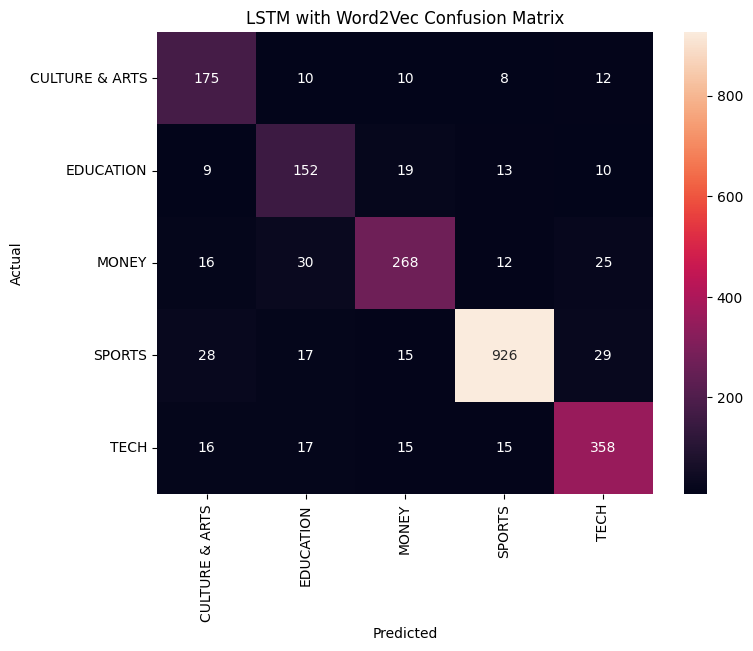

In [82]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_mapping.keys(),
    yticklabels=label_mapping.keys()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("LSTM with Word2Vec Confusion Matrix")

plt.show()

##**Misclassified Examples**

In [83]:
misclassified = np.where(y_pred != y_test)[0]

for i in misclassified[:10]:

    print("Headline :", test_df.iloc[i]['headline'])
    print("Cleaned  :", test_df.iloc[i]['cleaned_headline'])
    print("Actual   :", test_df.iloc[i]['category'])
    print("Predicted:", label_encoder.inverse_transform(
        [y_pred[i]]
    )[0])

    print("-" * 60)

Headline : The Game Boy Of Your Childhood Dreams Finally Exists
Cleaned  : game boy childhood dream finally exists
Actual   : TECH
Predicted: SPORTS
------------------------------------------------------------
Headline : Tales From The Autism Spectrum: My Friend AmberDawn...
Cleaned  : tale autism spectrum friend amberdawn
Actual   : CULTURE & ARTS
Predicted: EDUCATION
------------------------------------------------------------
Headline : Should I Go Back to Grad School?
Cleaned  : go back grad school
Actual   : MONEY
Predicted: EDUCATION
------------------------------------------------------------
Headline : Social Media Con Artists
Cleaned  : social medium con artist
Actual   : TECH
Predicted: CULTURE & ARTS
------------------------------------------------------------
Headline : 12 Photos Of Brazil Having One Big National Sad
Cleaned  : photo brazil one big national sad
Actual   : SPORTS
Predicted: CULTURE & ARTS
------------------------------------------------------------
Headline 

### **GUI**

In [86]:
# Reverse the class encoding
index_to_label = {int(v): k for k, v in label_mapping.items()}

available_models = {
    'Simple RNN':      model_rnn,
    'LSTM':            model_lstm,
    'LSTM + Word2Vec': model_glove,
}

def predict_headline(text, model_name):
    if not text.strip():
        return "Please enter a headline.", {}

    cleaned = clean_text(text)
    if not cleaned.strip():
        return "Text is empty after cleaning (all words removed as stopwords).", {}

    model  = available_models[model_name]
    seq    = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=100, padding='post', truncating='post')

    probs    = model.predict(padded, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_lbl = index_to_label[pred_idx]
    conf     = float(probs[pred_idx]) * 100

    confidences = {
        index_to_label[i]: float(probs[i])
        for i in range(len(probs))
    }

    summary = (
        f"### Predicted: {pred_lbl}\n\n"
        f"**Confidence:** {conf:.1f}%\n\n"
        f"**Cleaned text:** `{cleaned}`\n\n"
        f"**Model used:** {model_name}"
    )
    return summary, confidences

# Build the Gradio interface
with gr.Blocks(
    title="News Headline Classifier",
    theme=gr.themes.Soft(primary_hue="teal", neutral_hue="slate"),
) as demo:

    gr.Markdown("## News Headline Classifier")
    gr.Markdown("6CS012 Final Portfolio - Task 4.5.5 - Real-Time Prediction GUI")

    with gr.Row():
        with gr.Column(scale=3):
            text_input  = gr.Textbox(
                label="Enter a News Headline",
                placeholder='e.g. "NBA Finals: Lakers Win Championship in Overtime"',
                lines=3,
            )
            model_radio = gr.Radio(
                choices=list(available_models.keys()),
                value="LSTM + Word2Vec",
                label="Select Model",
            )
            predict_btn = gr.Button("Classify", variant="primary")

        with gr.Column(scale=2):
            result_md   = gr.Markdown(label="Prediction")
            result_conf = gr.Label(label="Confidence Scores", num_top_classes=5)

    with gr.Accordion("Example Headlines", open=False):
        gr.Examples(
            examples=[
                ["Lakers Win NBA Finals in Game 7 Overtime Thriller",            "LSTM + Word2Vec"],
                ["New AI Tool Writes Code Faster Than Human Developers",          "LSTM + Word2Vec"],
                ["Federal Reserve Raises Interest Rates Amid Inflation Concerns", "LSTM"],
                ["Harvard Introduces Free Online Machine Learning Course",         "LSTM"],
                ["Cannes Film Festival Announces Award Winners",                   "Simple RNN"],
            ],
            inputs=[text_input, model_radio],
            outputs=[result_md, result_conf],
            fn=predict_headline,
            cache_examples=False,
        )

    predict_btn.click(
        fn=predict_headline,
        inputs=[text_input, model_radio],
        outputs=[result_md, result_conf],
    )
    text_input.submit(
        fn=predict_headline,
        inputs=[text_input, model_radio],
        outputs=[result_md, result_conf],
    )

# Genereate the public link
demo.launch(share=True, debug=False)

/tmp/ipykernel_4171/2172542895.py:41: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e9e4445f0695856518.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
